In [1]:
from src.callbacks.extras import CountFlopsExtra
from src.utils import module_from_id, get_root, get_ckpt_path
from src.lightning_modules import DSB, Buddy, WPE, GFB, SGMSE
import os
import gc
import torch
from mamba_ssm import Mamba2

os.chdir(get_root())
device = 'cuda' if torch.cuda.is_available() else 'cpu'

/home/an/Documents/Latent-DSB/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/an/Documents/Latent-DSB/.venv/lib/python3.12/site-packages/speechbrain/utils/torch_audio_backend.py:64: UserWarning: torchaudio._backend.list_audio_backends has been deprecated. This deprecation is part of a large refactoring effort to transition TorchAudio into a maintenance phase. The decoding and encoding capabilities of PyTorch for both audio and video are being consolidated into TorchCodec. Please see https://github.com/pytorch/audio/issues/3902 for more information. It will be removed from the 2.9 release. 
  available_backends = torchaudio.list_audio_backends()
W0505 12:46:35.070000 42210 torch/utils/cpp_extension.py:2425] TORCH_CUDA_ARCH_LIST is not set, all archs for visible cards are included for compilat

In [2]:
id = "170426112440"
ckpt_filename = f"model-{id}:v0"

ckpt_path = get_ckpt_path(id, ckpt_filename)
DSB_Trained:DSB = module_from_id(id, ckpt_filename)
ckpt = torch.load(ckpt_path, map_location="cpu")
DSB_Trained.ema.load_state_dict(ckpt["ema"])
DSB_Trained.ema.copy_to(DSB_Trained.parameters())
DSB_Trained.to(device)

DSB(
  (model): Mamba2DiffusionModel(
    (down_conv): Conv1d(1, 512, kernel_size=(256,), stride=(16,), padding=(120,), bias=False)
    (up_conv): ConvTranspose1d(512, 1, kernel_size=(256,), stride=(16,), padding=(120,), bias=False)
    (y_embedder): Embedding(2, 512)
    (timestep_embedder): TimestepEmbedder(
      (mlp): Sequential(
        (0): Linear(in_features=256, out_features=512, bias=True)
        (1): SiLU()
        (2): Linear(in_features=512, out_features=512, bias=True)
      )
    )
    (blocks): ModuleList(
      (0-9): 10 x Mamba2DiffusionBlock(
        (adaln): AdaLN(
          (norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
          (scale_proj): Linear(in_features=512, out_features=512, bias=True)
          (shift_proj): Linear(in_features=512, out_features=512, bias=True)
        )
        (mamba_fwd): Mamba2(
          (in_proj): Linear(in_features=512, out_features=2320, bias=False)
          (conv1d): Conv1d(1280, 1280, kernel_size=(4,), stride=(1

In [3]:
BUDDY_100 = Buddy(num_steps=100)
BUDDY_100.to(device)

Loading state dict
dict_keys(['it', 'network', 'optimizer', 'ema', 'args'])
Attempt 1: trying with strict=True


Buddy(
  (network): NCSNppTime(
    (act): SiLU()
    (output_layer): Conv2d(2, 2, kernel_size=(1, 1), stride=(1, 1))
    (pyramid_upsample): Upsample()
    (pyramid_downsample): Downsample()
    (all_modules): ModuleList(
      (0): GaussianFourierProjection()
      (1): Linear(in_features=256, out_features=512, bias=True)
      (2): Linear(in_features=512, out_features=512, bias=True)
      (3): Conv2d(2, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): ResnetBlockBigGANpp(
        (GroupNorm_0): GroupNorm(32, 128, eps=1e-06, affine=True)
        (Conv_0): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (Dense_0): Linear(in_features=512, out_features=128, bias=True)
        (GroupNorm_1): GroupNorm(32, 128, eps=1e-06, affine=True)
        (Dropout_0): Dropout(p=0, inplace=False)
        (Conv_1): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (act): SiLU()
      )
      (5): ResnetBlockBigGANpp(
        (Group

In [4]:
BUDDY_10 = Buddy(num_steps=10)
BUDDY_10.to(device)

Loading state dict
dict_keys(['it', 'network', 'optimizer', 'ema', 'args'])
Attempt 1: trying with strict=True


Buddy(
  (network): NCSNppTime(
    (act): SiLU()
    (output_layer): Conv2d(2, 2, kernel_size=(1, 1), stride=(1, 1))
    (pyramid_upsample): Upsample()
    (pyramid_downsample): Downsample()
    (all_modules): ModuleList(
      (0): GaussianFourierProjection()
      (1): Linear(in_features=256, out_features=512, bias=True)
      (2): Linear(in_features=512, out_features=512, bias=True)
      (3): Conv2d(2, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): ResnetBlockBigGANpp(
        (GroupNorm_0): GroupNorm(32, 128, eps=1e-06, affine=True)
        (Conv_0): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (Dense_0): Linear(in_features=512, out_features=128, bias=True)
        (GroupNorm_1): GroupNorm(32, 128, eps=1e-06, affine=True)
        (Dropout_0): Dropout(p=0, inplace=False)
        (Conv_1): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (act): SiLU()
      )
      (5): ResnetBlockBigGANpp(
        (Group

In [5]:
GFB_Baseline = GFB(task='rir')
GFB_Baseline.to(device)

GFB(
  (model): STFTbackbone(
    (embedding): RFF_MLP_Block(
      (MLP): ModuleList(
        (0-2): 3 x Linear()
      )
    )
    (embedding_param): RFF_MLP_Block(
      (MLP): ModuleList(
        (0-2): 3 x Linear()
      )
    )
    (downsamplerT): UpDownResample()
    (downsamplerF): UpDownResample()
    (upsamplerT): UpDownResample()
    (upsamplerF): UpDownResample()
    (downs): ModuleList(
      (0): ModuleList(
        (0): ResnetBlock(
          (res_conv): Identity()
          (proj_in): Identity()
          (H): ModuleList(
            (0): Conv2d()
          )
          (affine): ModuleList(
            (0): Linear()
          )
          (gate): ModuleList(
            (0): Linear()
          )
          (norm): ModuleList(
            (0): BiasFreeGroupNorm()
          )
        )
      )
      (1-3): 3 x ModuleList(
        (0): ResnetBlock(
          (res_conv): Conv2d()
          (proj_in): Conv2d()
          (H): ModuleList(
            (0): Conv2d()
          )
  

In [6]:
SGMSE_Baseline = SGMSE()
SGMSE_Baseline.to(device)

Downloading...
From (original): https://drive.google.com/uc?id=1eiOy0VjHh9V9ZUFTxu1Pq2w19izl9ejD
From (redirected): https://drive.google.com/uc?id=1eiOy0VjHh9V9ZUFTxu1Pq2w19izl9ejD&confirm=t&uuid=87088e03-34d3-4a7b-a226-2b8837cf44fd
To: /home/an/Documents/Latent-DSB-Data/hf_cache/sgmse_natural_rir_350k.ckpt
100%|██████████| 1.31G/1.31G [01:27<00:00, 15.0MB/s]
Lightning automatically upgraded your loaded checkpoint from v1.6.4 to v2.6.0. To apply the upgrade to your files permanently, run `python -m pytorch_lightning.utilities.upgrade_checkpoint ../Latent-DSB-Data/hf_cache/sgmse_natural_rir_350k.ckpt`


SGMSE(
  (model): ScoreModel(
    (dnn): NCSNpp(
      (act): SiLU()
      (output_layer): Conv2d(4, 2, kernel_size=(1, 1), stride=(1, 1))
      (pyramid_upsample): Upsample()
      (pyramid_downsample): Downsample()
      (all_modules): ModuleList(
        (0): GaussianFourierProjection()
        (1): Linear(in_features=256, out_features=512, bias=True)
        (2): Linear(in_features=512, out_features=512, bias=True)
        (3): Conv2d(4, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (4-5): 2 x ResnetBlockBigGANpp(
          (GroupNorm_0): GroupNorm(32, 128, eps=1e-06, affine=True)
          (Conv_0): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (Dense_0): Linear(in_features=512, out_features=128, bias=True)
          (GroupNorm_1): GroupNorm(32, 128, eps=1e-06, affine=True)
          (Dropout_0): Dropout(p=0.0, inplace=False)
          (Conv_1): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (act): Si

In [7]:
WPE_Baseline = WPE()
WPE_Baseline.to(device)

WPE()

In [8]:
dummy_batch = {
    "audio": torch.randn(1, 1, 2**15, device=device) # Adjust key and shape as needed. 1s Audio as a default.
}

In [9]:
flop_extra_DSB_10 = CountFlopsExtra(
    key="audio", 
    display_table=True, 
    num_steps=10, 
    direction="forward",
    verbose = True
)

flop_extra_DSB_50 = CountFlopsExtra(
    key="audio", 
    display_table=True, 
    num_steps=50, 
    direction="forward",
    verbose = True
)

flop_extra_Buddy_10 = CountFlopsExtra(
    key="audio", 
    display_table=True, 
    num_steps=10,
    verbose = True,
)

flop_extra_Buddy_100 = CountFlopsExtra(
    key="audio", 
    display_table=True, 
    num_steps=100,
    verbose = True,
)

flop_extra_GFB_10 = CountFlopsExtra(
    key="audio", 
    display_table=True, 
    num_steps=10,
    verbose = True,
)

flop_extra_GFB_50 = CountFlopsExtra(
    key="audio", 
    display_table=True, 
    num_steps=50,
    verbose = True,
)

flop_extra_SGMSE_10 = CountFlopsExtra(
    key="audio", 
    display_table=True, 
    num_steps=10,
    verbose = True,
)

flop_extra_SGMSE_50 = CountFlopsExtra(
    key="audio", 
    display_table=True, 
    num_steps=50,
    verbose = True,
)

flop_extra_WPE = CountFlopsExtra(
    key="audio", 
    display_table=True, 
    verbose = True,
)

In [10]:
result_DSB_10 = flop_extra_DSB_10(pl_module=DSB_Trained, batch=dummy_batch, batch_idx=0)


Module                            FLOP    % Total
---------------------------  ---------  ---------
Global                       1629.014B    100.00%
 - aten.convolution            10.737B      0.66%
 - aten.mul                     0.106B      0.01%
 - aten.addmm                 214.861B     13.19%
 - aten.silu                    0.000B      0.00%
 - aten.add                     0.210B      0.01%
 - aten.native_layer_norm       0.524B      0.03%
 - aten.mm                   1402.575B     86.10%
 DSB                         1629.013B    100.00%
  - aten.convolution           10.737B      0.66%
  - aten.mul                    0.105B      0.01%
  - aten.addmm                214.861B     13.19%
  - aten.silu                   0.000B      0.00%
  - aten.add                    0.210B      0.01%
  - aten.native_layer_norm      0.524B      0.03%
  - aten.mm                  1402.575B     86.10%
  DSB.model                  1629.013B    100.00%
   - aten.convolution          10.737B      0.66%


In [11]:
gc.collect()
torch.cuda.empty_cache()

In [12]:
result_DSB_50 = flop_extra_DSB_50(pl_module=DSB_Trained, batch=dummy_batch, batch_idx=0)


Module                            FLOP    % Total
---------------------------  ---------  ---------
Global                       8145.070B    100.00%
 - aten.convolution            53.687B      0.66%
 - aten.mul                     0.528B      0.01%
 - aten.addmm                1074.305B     13.19%
 - aten.silu                    0.000B      0.00%
 - aten.add                     1.052B      0.01%
 - aten.native_layer_norm       2.621B      0.03%
 - aten.mm                   7012.876B     86.10%
 DSB                         8145.064B    100.00%
  - aten.convolution           53.687B      0.66%
  - aten.mul                    0.524B      0.01%
  - aten.addmm               1074.305B     13.19%
  - aten.silu                   0.000B      0.00%
  - aten.add                    1.049B      0.01%
  - aten.native_layer_norm      2.621B      0.03%
  - aten.mm                  7012.876B     86.10%
  DSB.model                  8145.064B    100.00%
   - aten.convolution          53.687B      0.66%


In [13]:
gc.collect()
torch.cuda.empty_cache()

In [14]:
result_BUDDY_10 = flop_extra_Buddy_10(pl_module=BUDDY_10, batch=dummy_batch, batch_idx=0)


Processing WPE


100%|██████████| 10/10 [00:05<00:00,  1.94it/s]

Module                              FLOP    % Total
-------------------------------  -------  ---------
Global                           19.213T    100.00%
 - aten.mul                       0.006T      0.03%
 - aten.add                       0.004T      0.02%
 - aten.add_                      0.001T      0.00%
 - aten.addmm                     0.000T      0.00%
 - aten.silu                      0.009T      0.05%
 - aten.convolution               6.625T     34.48%
 - aten.bmm                       0.048T      0.25%
 - aten.mul_                      0.000T      0.00%
 - aten.convolution_backward     12.519T     65.16%
 NCSNppTime                      13.293T     69.19%
  - aten.mul                      0.006T      0.03%
  - aten.addmm                    0.000T      0.00%
  - aten.silu                     0.009T      0.05%
  - aten.convolution              6.613T     34.42%
  - aten.add_                     0.001T      0.00%
  - aten.add                      0.004T      0.02%
  - aten.bmm

In [15]:
gc.collect()
torch.cuda.empty_cache()

In [16]:
result_BUDDY_100 = flop_extra_Buddy_100(pl_module=BUDDY_100, batch=dummy_batch, batch_idx=0)


Processing WPE


100%|██████████| 100/100 [00:48<00:00,  2.08it/s]

Module                               FLOP    % Total
-------------------------------  --------  ---------
Global                           192.127T    100.00%
 - aten.mul                        0.064T      0.03%
 - aten.add                        0.042T      0.02%
 - aten.add_                       0.007T      0.00%
 - aten.addmm                      0.001T      0.00%
 - aten.silu                       0.093T      0.05%
 - aten.convolution               66.251T     34.48%
 - aten.bmm                        0.478T      0.25%
 - aten.mul_                       0.000T      0.00%
 - aten.convolution_backward     125.191T     65.16%
 NCSNppTime                      132.929T     69.19%
  - aten.mul                       0.056T      0.03%
  - aten.addmm                     0.001T      0.00%
  - aten.silu                      0.093T      0.05%
  - aten.convolution              66.128T     34.42%
  - aten.add_                      0.007T      0.00%
  - aten.add                       0.040T     

In [17]:
gc.collect()
torch.cuda.empty_cache()

In [18]:
result_GFB_10 = flop_extra_GFB_10(pl_module=GFB_Baseline, batch=dummy_batch, batch_idx=0)


Module                               FLOP    % Total
------------------------------  ---------  ---------
Global                          2426.539B    100.00%
 - aten.mul                        1.842B      0.08%
 - aten.add                        1.114B      0.05%
 - aten.mm                         0.299B      0.01%
 - aten.add_                       0.000B      0.00%
 - aten.convolution             2423.285B     99.87%
 STFTbackbone                   2426.537B    100.00%
  - aten.mul                       1.840B      0.08%
  - aten.mm                        0.299B      0.01%
  - aten.add_                      0.000B      0.00%
  - aten.convolution            2423.285B     99.87%
  - aten.add                       1.113B      0.05%
  STFTbackbone.downsamplerF       77.135B      3.18%
   - aten.convolution             77.135B      3.18%
  STFTbackbone.downsamplerT      308.539B     12.72%
   - aten.convolution            308.539B     12.72%
  STFTbackbone.embedding           0.006B     

In [19]:
gc.collect()
torch.cuda.empty_cache()

In [22]:
result_GFB_50 = flop_extra_GFB_50(pl_module=GFB_Baseline, batch=dummy_batch, batch_idx=0)


Module                             FLOP    % Total
------------------------------  -------  ---------
Global                          13.211T    100.00%
 - aten.mul                      0.010T      0.08%
 - aten.add                      0.006T      0.05%
 - aten.mm                       0.002T      0.01%
 - aten.add_                     0.000T      0.00%
 - aten.convolution             13.193T     99.87%
 STFTbackbone                   13.211T    100.00%
  - aten.mul                     0.010T      0.08%
  - aten.mm                      0.002T      0.01%
  - aten.add_                    0.000T      0.00%
  - aten.convolution            13.193T     99.87%
  - aten.add                     0.006T      0.05%
  STFTbackbone.downsamplerF      0.420T      3.18%
   - aten.convolution            0.420T      3.18%
  STFTbackbone.downsamplerT      1.680T     12.72%
   - aten.convolution            1.680T     12.72%
  STFTbackbone.embedding         0.000T      0.00%
   - aten.mul                  

In [23]:
gc.collect()
torch.cuda.empty_cache()

In [24]:
result_SGMSE_10 = flop_extra_SGMSE_10(pl_module=SGMSE_Baseline, batch=dummy_batch, batch_idx=0)


Module                    FLOP    % Total
---------------------  -------  ---------
Global                 13.334T    100.00%
 - aten.mul             0.000T      0.00%
 - aten.add             0.002T      0.02%
 - aten.addmm           0.000T      0.00%
 - aten.silu            0.025T      0.19%
 - aten.convolution    13.288T     99.66%
 - aten.add_            0.002T      0.01%
 - aten.bmm             0.017T      0.12%
 ScoreModel            13.334T    100.00%
  - aten.mul            0.000T      0.00%
  - aten.addmm          0.000T      0.00%
  - aten.silu           0.025T      0.19%
  - aten.convolution   13.288T     99.66%
  - aten.add_           0.002T      0.01%
  - aten.add            0.002T      0.02%
  - aten.bmm            0.017T      0.12%
  ScoreModel.dnn       13.334T    100.00%
   - aten.mul           0.000T      0.00%
   - aten.addmm         0.000T      0.00%
   - aten.silu          0.025T      0.19%
   - aten.convolution  13.288T     99.66%
   - aten.add_          0.002T    

In [25]:
gc.collect()
torch.cuda.empty_cache()

In [26]:
result_SGMSE_50 = flop_extra_SGMSE_50(pl_module=SGMSE_Baseline, batch=dummy_batch, batch_idx=0)


Module                    FLOP    % Total
---------------------  -------  ---------
Global                 66.669T    100.00%
 - aten.mul             0.000T      0.00%
 - aten.add             0.010T      0.02%
 - aten.addmm           0.001T      0.00%
 - aten.silu            0.125T      0.19%
 - aten.convolution    66.440T     99.66%
 - aten.add_            0.010T      0.01%
 - aten.bmm             0.083T      0.12%
 ScoreModel            66.669T    100.00%
  - aten.mul            0.000T      0.00%
  - aten.addmm          0.001T      0.00%
  - aten.silu           0.125T      0.19%
  - aten.convolution   66.440T     99.66%
  - aten.add_           0.010T      0.01%
  - aten.add            0.010T      0.02%
  - aten.bmm            0.083T      0.12%
  ScoreModel.dnn       66.669T    100.00%
   - aten.mul           0.000T      0.00%
   - aten.addmm         0.001T      0.00%
   - aten.silu          0.125T      0.19%
   - aten.convolution  66.440T     99.66%
   - aten.add_          0.010T    

In [28]:
gc.collect()
torch.cuda.empty_cache()

In [29]:
result_WPE = flop_extra_WPE(pl_module=WPE_Baseline, batch=dummy_batch, batch_idx=0)


Module      FLOP    % Total
--------  ------  ---------
Global         0         0%

Dispatcher FLOPs (Table): 0.00 Billion
Hidden Mamba FLOPs (Hooks): 0.00 Billion
Hidden WPE FLOPs (Hooks): 1.20 Billion
True Total: 1.20 Billion



In [30]:
gc.collect()
torch.cuda.empty_cache()

In [31]:
#from mamba_ssm import Mamba2a
#for module in DSB_10.modules():
#    if isinstance(module,Mamba2):
#        print(module.__total_flops__)

In [32]:
with torch.profiler.profile(
    activities=[torch.profiler.ProfilerActivity.CPU, torch.profiler.ProfilerActivity.CUDA]
) as prof:
    DSB_Trained.sample(dummy_batch["audio"], direction="forward", num_steps=10)

print(prof.key_averages().table(sort_by="cuda_time_total"))

-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                                   Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg     Self CUDA   Self CUDA %    CUDA total  CUDA time avg    # of Calls  
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                         MambaSplitConv1dScanCombinedFn        17.00%     112.195ms        34.26%     226.181ms       1.131ms     223.074ms        32.97%     397.094ms       1.985ms           200  
                                           aten::linear         0.21%       1.406ms        20.30%     134.002ms     186.114us       0.000us         0.00%     324.701ms     450.973us           720  
         

In [33]:
with torch.profiler.profile(
    activities=[torch.profiler.ProfilerActivity.CPU, torch.profiler.ProfilerActivity.CUDA]
) as prof:
    BUDDY_10.sample(dummy_batch["audio"], num_steps=10)

print(prof.key_averages().table(sort_by="cuda_time_total"))

Processing WPE


100%|██████████| 10/10 [00:03<00:00,  3.07it/s]


-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                                   Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg     Self CUDA   Self CUDA %    CUDA total  CUDA time avg    # of Calls  
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
autograd::engine::evaluate_function: ConvolutionBack...         0.25%       7.333ms         1.95%      56.113ms      44.184us       0.000us         0.00%     741.863ms     584.144us          1270  
                                   ConvolutionBackward0         0.06%       1.857ms         1.59%      45.889ms      36.133us       0.000us         0.00%     740.170ms     582.811us          1270  
         

In [34]:
with torch.profiler.profile(
    activities=[torch.profiler.ProfilerActivity.CPU, torch.profiler.ProfilerActivity.CUDA]
) as prof:
    GFB_Baseline.sample(dummy_batch["audio"], num_steps=10)

print(prof.key_averages().table(sort_by="cuda_time_total"))

-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                                   Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg     Self CUDA   Self CUDA %    CUDA total  CUDA time avg    # of Calls  
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                      aten::convolution         0.30%       2.393ms         7.34%      59.540ms      33.926us       0.000us         0.00%     477.900ms     272.308us          1755  
                                     aten::_convolution         0.61%       4.908ms         7.05%      57.147ms      32.562us       0.000us         0.00%     477.900ms     272.308us          1755  
         

In [35]:
with torch.profiler.profile(
    activities=[torch.profiler.ProfilerActivity.CPU, torch.profiler.ProfilerActivity.CUDA]
) as prof:
    SGMSE_Baseline.sample(dummy_batch["audio"], num_steps=10)

print(prof.key_averages().table(sort_by="cuda_time_total"))

-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                                   Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg     Self CUDA   Self CUDA %    CUDA total  CUDA time avg    # of Calls  
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                           aten::conv2d         0.10%       2.429ms         5.32%     130.377ms      44.346us       0.000us         0.00%        1.551s     527.434us          2940  
                                      aten::convolution         0.20%       4.954ms         5.22%     127.949ms      43.520us       0.000us         0.00%        1.551s     527.434us          2940  
         

In [36]:
with torch.profiler.profile(
    activities=[torch.profiler.ProfilerActivity.CPU, torch.profiler.ProfilerActivity.CUDA]
) as prof:
    WPE_Baseline.sample(dummy_batch["audio"], num_steps=10)

print(prof.key_averages().table(sort_by="cuda_time_total"))

---------------------------  ------------  ------------  ------------  ------------  ------------  ------------  
                       Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg    # of Calls  
---------------------------  ------------  ------------  ------------  ------------  ------------  ------------  
               aten::unbind         0.46%      11.287us         1.07%      25.971us      25.971us             1  
               aten::select         0.42%      10.179us         0.60%      14.684us      14.684us             1  
           aten::as_strided         0.27%       6.577us         0.27%       6.577us       3.289us             2  
                   aten::to         0.27%       6.598us        77.07%       1.875ms     468.709us             4  
             aten::_to_copy         0.83%      20.271us        76.80%       1.868ms     622.746us             3  
        aten::empty_strided         3.25%      79.110us         3.25%      79.110us     

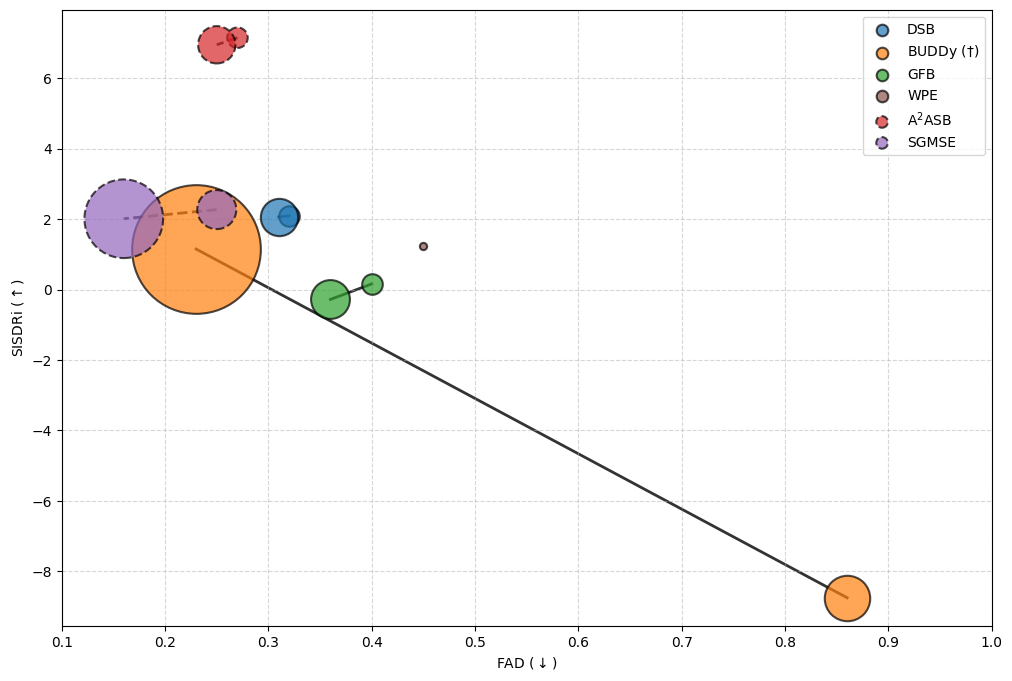

In [54]:
import matplotlib.pyplot as plt
import numpy as np

fig, axs = plt.subplots(figsize=(12, 8))

# Coordinates
dsb10 = [0.32, 2.09]
dsb50 = [0.31, 2.06]
buddy10 = [0.86, -8.75]
buddy100 = [0.23, 1.15]
gfb10 = [0.4, 0.16]
gfb50 = [0.36, -0.28]
wpe = [0.45, 1.24]
#Paired baselines
a2asb10 = [0.27,7.15]
a2asb50 = [0.25,6.95]
sgmse10 = [0.25,2.27]
sgmse50 = [0.16,2.01]

# GFLOPs sizes
dsb10_size = 2393.74
dsb50_size = 11968.70
buddy10_size = 19212.73
buddy100_size = 192127.31
gfb10_size = 2426.54
gfb50_size = 13211.16
wpe_size = 1.20
#Paired baselines
a2asb10_size = dsb10_size
a2asb50_size = dsb50_size
sgmse10_size = 13333.80
sgmse50_size = 66669.01

radius_scale_factor = 0.2  # How much the log value affects the radius
base_radius = 5         # Minimum radius size

def calc_size(flops):
    """Calculates marker area so the *area* scales linearly with FLOPs."""
    desired_radius = (np.sqrt(flops) * radius_scale_factor) + base_radius
    return desired_radius ** 2  # Square it because 's' expects area

# Family colors
colors = plt.cm.tab10.colors
c_dsb = colors[0]
c_buddy = colors[1]
c_gfb = colors[2]
c_a2asb = colors[3]
c_sgmse = colors[4]
c_wpe = colors[5]

# Styling
style = {'alpha': 0.7, 'edgecolors': 'black', 'linewidths': 1.5, 'zorder': 2}
style_paired = {'alpha': 0.7, 'edgecolors': 'black', 'linewidths': 1.5, 'linestyles': '--', 'zorder': 2}
style_line = {'alpha': 0.8, 'linewidth': 2, 'zorder':1, 'c':'k'}
style_line_paired = {'alpha': 0.8, 'linewidth': 2, 'zorder':1, 'c':'k', 'linestyle': '--'}

# Plotting
# Format: axs.plot([x1, x2], [y1, y2], ...)
axs.plot([dsb10[0], dsb50[0]], [dsb10[1], dsb50[1]], **style_line)
axs.plot([buddy10[0], buddy100[0]], [buddy10[1], buddy100[1]], **style_line)
axs.plot([gfb10[0], gfb50[0]], [gfb10[1], gfb50[1]], **style_line)
axs.plot([a2asb10[0], a2asb50[0]], [a2asb10[1], a2asb50[1]], **style_line_paired)
axs.plot([sgmse10[0], sgmse50[0]], [sgmse10[1], sgmse50[1]], **style_line_paired)

axs.scatter(*dsb10, s=calc_size(dsb10_size), color=c_dsb, label="DSB", **style)
axs.scatter(*dsb50, s=calc_size(dsb50_size), color=c_dsb, **style)

axs.scatter(*buddy10, s=calc_size(buddy10_size), color=c_buddy, label=rf"BUDDy ($\dagger$)", **style)
axs.scatter(*buddy100, s=calc_size(buddy100_size), color=c_buddy, **style)

axs.scatter(*gfb10, s=calc_size(gfb10_size), color=c_gfb, label="GFB", **style)
axs.scatter(*gfb50, s=calc_size(gfb50_size), color=c_gfb, **style)

axs.scatter(*wpe, s=calc_size(wpe_size), color=c_wpe, label="WPE", **style)

axs.scatter(*a2asb10, s=calc_size(a2asb10_size), color=c_a2asb, label=fr"A$^2$ASB", **style_paired)
axs.scatter(*a2asb50, s=calc_size(a2asb50_size), color=c_a2asb, **style_paired)

axs.scatter(*sgmse10, s=calc_size(sgmse10_size), color=c_sgmse, label="SGMSE", **style_paired)
axs.scatter(*sgmse50, s=calc_size(sgmse50_size), color=c_sgmse, **style_paired)

# Legend
leg = axs.legend()
for handle in leg.legend_handles:
    handle.set_sizes([70]) 

axs.set_ylabel(r"SISDRi $(\uparrow)$")
axs.set_xlabel(r"FAD $(\downarrow)$")
axs.set_xlim(0.1,1)
axs.grid(True, linestyle='--', alpha=0.5)

plt.show()